# Encoder transform analysis — does the learned encoder act Hadamard-like?

Compare four candidate transforms on 1024-dim weight rows:
1. **No transform** — identity
2. **Scaling** — per-channel std normalization
3. **Random Hadamard Rotation (RHR)** — 1024×1024 H · diag(±1)
4. **Learned** — block-diagonal application of the trained `g_a` (encoder) on 16-dim chunks (1024 = 64 × 16). Multiple λ checkpoints loaded.

Datasets: Gaussian and Llama-3-8B (per-tensor std normalized).

Tests:
- **Orthogonality**: ‖JᵀJ − αI‖_F (small ⇒ rotation-like up to scale)
- **Entry distribution**: histogram of |J_ij|; row-wise max-to-mean ratio (low ⇒ uniform)
- **Energy mixing**: how does e_i (basis input) spread across output dims? (high participation-ratio ⇒ Hadamard-like)
- **Covariance whitening**: condition number of cov(f(X))

In [21]:
import math, os, sys, glob, argparse
from pathlib import Path
from collections import OrderedDict

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '/home/jgryu/workspace/weight_compression/NWC_v2')
sys.path.append('/home/jgryu/workspace/weight_compression')          # NWC.* imports
sys.path.append('/home/jgryu/workspace/weight_compression/NWC')      # LTC submodule
from models.codec import NWCv2Codec

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float32

INPUT_DIM = 1024
BLOCK_DIM = 16
N_BLOCKS  = INPUT_DIM // BLOCK_DIM
N_SAMPLES = 1024
assert INPUT_DIM % BLOCK_DIM == 0

CKPT_GLOB = '/home/jgryu/workspace/weight_compression/NWC_v2/checkpoint/rd_sweep/llama8b_resblock-resblock_compressai_M16_lmbda{l}/best.pth.tar'
# LAMBDAS   = [32, 128, 1024, 8192]
LAMBDAS   = [32]

FIG_DIR = Path('/home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('device', DEVICE, '/ INPUT_DIM', INPUT_DIM, '/ BLOCK_DIM', BLOCK_DIM, '/ N_SAMPLES', N_SAMPLES)

device cuda / INPUT_DIM 1024 / BLOCK_DIM 16 / N_SAMPLES 1024


## 1. Data sampling

In [22]:
def sample_gaussian(n_samples=N_SAMPLES, dim=INPUT_DIM, std=1.0, seed=0):
    g = torch.Generator().manual_seed(seed)
    return torch.randn(n_samples, dim, generator=g) * std


def sample_llama8b_tensor_normed(n_samples=N_SAMPLES, dim=INPUT_DIM,
                                 hf_path='/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B',
                                 max_layers=None, seed=0):
    """Pull rows of length `dim` from every nn.Linear in Llama, after dividing
    each Linear weight by its own scalar std (per-tensor normalize)."""
    from datasets.llama8b import get_blocks, get_named_linears
    from transformers import AutoModelForCausalLM
    g = torch.Generator().manual_seed(seed)
    model = AutoModelForCausalLM.from_pretrained(hf_path, local_files_only=True)
    layers = get_blocks(model)
    if max_layers is not None:
        layers = layers[:max_layers]
    rows = []
    for i in range(len(layers)):
        for n, m in get_named_linears(layers[i]).items():
            W = m.weight.data.detach().float()                        # (out, in)
            tstd = W.std().clamp_min(1e-12)
            Wn = W / tstd
            for axis_W in (Wn, Wn.T):
                if axis_W.shape[1] >= dim:
                    n_full = axis_W.shape[1] // dim
                    rows.append(axis_W[:, :n_full * dim].reshape(-1, dim))
    pool = torch.cat(rows, dim=0)
    idx = torch.randperm(pool.shape[0], generator=g)[:n_samples]
    return pool[idx]


X_GAUSS = sample_gaussian().to(DEVICE)
print('gaussian:', X_GAUSS.shape, 'mean', float(X_GAUSS.mean()), 'std', float(X_GAUSS.std()))

gaussian: torch.Size([1024, 1024]) mean -0.0011804751120507717 std 0.9998361468315125


In [23]:
# Llama loading is slow + needs ~16 GB RAM; max_layers limits to N first decoder blocks.
X_LLAMA = sample_llama8b_tensor_normed(max_layers=4).to(DEVICE)
print('llama8b:', X_LLAMA.shape, 'mean', float(X_LLAMA.mean()), 'std', float(X_LLAMA.std()))

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 7/7 [00:01<00:00,  4.54it/s]


llama8b: torch.Size([1024, 1024]) mean 0.00033912097569555044 std 0.9991042613983154


## 2. Define the 4 transforms
Each is a callable mapping `(B, INPUT_DIM) -> (B, INPUT_DIM)`.

In [24]:
def make_identity_transform():
    return (lambda x: x.clone())


def make_scaling_transform(X_ref):
    """Per-channel std on a reference batch and divide by it."""
    std = X_ref.float().std(dim=0).clamp_min(1e-9).to(DEVICE)
    def f(x):
        return x / std.unsqueeze(0)
    return f


def hadamard_matrix(n: int):
    """Sylvester construction; n must be a power of 2. Normalized to 1/sqrt(n) for orthogonal."""
    if (n & (n - 1)) != 0:
        raise ValueError(f'n must be power of 2, got {n}')
    H = torch.tensor([[1.0]])
    while H.shape[0] < n:
        H = torch.cat([torch.cat([H, H], dim=1),
                       torch.cat([H, -H], dim=1)], dim=0)
    return H / math.sqrt(n)


def make_rht_transform(dim=INPUT_DIM, seed=0):
    g = torch.Generator().manual_seed(seed)
    diag = (torch.randint(0, 2, (dim,), generator=g).mul(2).sub(1)).float().to(DEVICE)
    H = hadamard_matrix(dim).to(DEVICE)
    def f(x):
        return (x * diag.unsqueeze(0)) @ H.T
    return f


def load_learned_encoder(ckpt_path: str):
    saved = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    a = saved.get('args', {})
    args = argparse.Namespace(**a)
    model = NWCv2Codec(args,
                       scale=torch.tensor(1.0, dtype=DTYPE),
                       shift=torch.tensor(0.0, dtype=DTYPE))
    sd = saved['state_dict']
    # Drop CDF buffers (different shape between fresh model and trained ckpt);
    # they're rebuilt below by entropy_bottleneck.update() from loaded quantiles.
    drop = {'scale', 'shift',
            'entropy_bottleneck._offset',
            'entropy_bottleneck._quantized_cdf',
            'entropy_bottleneck._cdf_length'}
    sd = OrderedDict((k, v) for k, v in sd.items() if k not in drop)
    model.load_state_dict(sd, strict=False)
    try:
        model.entropy_bottleneck.update(force=True)
    except Exception as e:
        print(f'  [warn] EB.update failed: {e}')
    model.eval().to(DEVICE)
    return model, args


def make_learned_transform(ckpt_path: str):
    model, args = load_learned_encoder(ckpt_path)
    encoder = model.g_a   # (B, T, 16) -> (B, T, 16)
    block = int(args.input_size)
    def f(x):
        # x: (B, INPUT_DIM)  ->  (B, N_BLOCKS, block) -> encoder -> flatten back
        B, D = x.shape
        nb = D // block
        y = encoder(x.reshape(B, nb, block).contiguous())
        return y.reshape(B, D)
    return f, args


TRANSFORMS = {}
for X_ref, ds_name in [(X_GAUSS, 'gaussian'), (X_LLAMA, 'llama8b')]:
    Tdict = OrderedDict()
    Tdict['no_transform'] = make_identity_transform()
    Tdict['scaling']      = make_scaling_transform(X_ref)
    Tdict['rht']          = make_rht_transform(dim=INPUT_DIM, seed=0)
    for L in LAMBDAS:
        ckpt = CKPT_GLOB.format(l=L)
        if not os.path.exists(ckpt):
            print(f'  [skip] checkpoint not found: {ckpt}')
            continue
        Tdict[f'learned(λ={L})'], _ = make_learned_transform(ckpt)
    TRANSFORMS[ds_name] = Tdict
    print(f'{ds_name}: {list(Tdict.keys())}')


gaussian: ['no_transform', 'scaling', 'rht', 'learned(λ=32)']
llama8b: ['no_transform', 'scaling', 'rht', 'learned(λ=32)']


## 3. Jacobian computation
Closed-form for trivial transforms; per-block autograd for the learned encoder (block-diagonal).

In [25]:
from torch.func import jacrev

def jacobian_full(f, x_anchor):
    """Dense Jacobian via torch.func.jacrev.  x_anchor: (D,) tensor."""
    def f_one(z):
        return f(z.unsqueeze(0)).squeeze(0)
    return jacrev(f_one)(x_anchor)


def jacobian_blocks(f, x_anchor, block_dim=BLOCK_DIM):
    """Block-diagonal Jacobian.  Returns (n_blocks, block_dim, block_dim)."""
    D = x_anchor.shape[0]
    nb = D // block_dim
    blocks = []
    for i in range(nb):
        seg = x_anchor[i*block_dim:(i+1)*block_dim].clone()
        def f_block(z, _i=i):
            x_full = x_anchor.clone()
            x_full[_i*block_dim:(_i+1)*block_dim] = z
            y_full = f(x_full.unsqueeze(0)).squeeze(0)
            return y_full[_i*block_dim:(_i+1)*block_dim]
        blocks.append(jacrev(f_block)(seg))
    return torch.stack(blocks, dim=0)


def assemble_block_diagonal(blocks, total_dim):
    nb, b, _ = blocks.shape
    J = torch.zeros(total_dim, total_dim, device=blocks.device, dtype=blocks.dtype)
    for i in range(nb):
        J[i*b:(i+1)*b, i*b:(i+1)*b] = blocks[i]
    return J


def compute_jacobian(name, f, x_anchor):
    """Dispatch.  Returns dense (D, D) Jacobian."""
    D = x_anchor.shape[0]
    if name == 'no_transform':
        return torch.eye(D, device=x_anchor.device)
    if name == 'scaling':
        scale = f(torch.ones_like(x_anchor).unsqueeze(0))[0]   # diagonal
        return torch.diag(scale)
    if name == 'rht':
        return jacobian_full(f, x_anchor)
    if name.startswith('learned'):
        blocks = jacobian_blocks(f, x_anchor, block_dim=BLOCK_DIM)
        return assemble_block_diagonal(blocks, D)
    raise ValueError(name)

## 4. Tests

In [26]:
@torch.no_grad()
def orthogonality_metric(J: torch.Tensor) -> dict:
    """‖JᵀJ − αI‖_F / ‖αI‖_F where α = trace(JᵀJ)/D (best scale match)."""
    D = J.shape[0]
    G = J.T @ J
    alpha = float(torch.trace(G).item()) / D
    diff = G - alpha * torch.eye(D, device=J.device)
    return {
        'alpha': alpha,
        'frob_diff_rel': float(torch.linalg.norm(diff).item()) /
                         max(float(torch.linalg.norm(alpha * torch.eye(D, device=J.device)).item()), 1e-12),
    }


@torch.no_grad()
def entry_distribution_metric(J: torch.Tensor) -> dict:
    """Per-row max-to-mean ratio of |J_ij|."""
    A = J.abs()
    row_mean = A.mean(dim=1).clamp_min(1e-12)
    row_max  = A.max(dim=1).values
    ratio = (row_max / row_mean)
    return {
        'max_to_mean_median': float(ratio.median().item()),
        'max_to_mean_mean':   float(ratio.mean().item()),
        'A_flat': A.flatten().cpu().numpy(),
    }


@torch.no_grad()
def energy_mixing_metric(J: torch.Tensor) -> dict:
    """Participation ratio per input basis (column).  PR = (Σ|a|)² / Σa²."""
    A = J.abs()
    col_sum  = A.sum(dim=0)
    col_l2sq = (A ** 2).sum(dim=0).clamp_min(1e-12)
    pr = (col_sum ** 2) / col_l2sq
    return {
        'participation_median': float(pr.median().item()),
        'participation_mean':   float(pr.mean().item()),
        'pr_per_col': pr.cpu().numpy(),
    }


@torch.no_grad()
def covariance_metrics(X_in: torch.Tensor, X_out: torch.Tensor) -> dict:
    def cov_stats(X):
        Xc = X - X.mean(dim=0, keepdim=True)
        C = (Xc.T @ Xc) / (X.shape[0] - 1)
        eig = torch.linalg.eigvalsh(C).clamp_min(1e-12)
        diag = torch.diag(C)
        off  = C - torch.diag(diag)
        return {
            'cond':     float((eig.max() / eig.min()).item()),
            'diag_dom': float((off.abs().sum() / diag.abs().sum().clamp_min(1e-12)).item()),
        }
    return {'pre': cov_stats(X_in), 'post': cov_stats(X_out)}

In [27]:
RESULTS  = {}      # RESULTS[(dataset, name)] = dict of metrics
JACOBIANS = {}     # cache for plotting

for ds_name, X in [('gaussian', X_GAUSS), ('llama8b', X_LLAMA)]:
    Tdict = TRANSFORMS[ds_name]
    anchor = X[0].clone()
    for tname, tf in Tdict.items():
        print(f'[{ds_name}] {tname} ...', end=' ')
        J = compute_jacobian(tname, tf, anchor)
        JACOBIANS[(ds_name, tname)] = J.detach().cpu()
        with torch.no_grad():
            X_out = tf(X)
        m = {
            'orthogonality': orthogonality_metric(J),
            'entries':       entry_distribution_metric(J),
            'energy':        energy_mixing_metric(J),
            'covariance':    covariance_metrics(X, X_out),
        }
        RESULTS[(ds_name, tname)] = m
        print(f'  ortho_rel={m["orthogonality"]["frob_diff_rel"]:.3f}, '
              f'm2m_med={m["entries"]["max_to_mean_median"]:.2f}, '
              f'pr_med={m["energy"]["participation_median"]:.1f}, '
              f'cond_post={m["covariance"]["post"]["cond"]:.2e}')

[gaussian] no_transform ...   ortho_rel=0.000, m2m_med=1024.00, pr_med=1.0, cond_post=1.35e+07
[gaussian] scaling ...   ortho_rel=0.044, m2m_med=1024.00, pr_med=1.0, cond_post=7.23e+06
[gaussian] rht ...   ortho_rel=0.000, m2m_med=1.00, pr_med=1024.0, cond_post=3.06e+06
[gaussian] learned(λ=32) ... 

  ortho_rel=0.014, m2m_med=227.26, pr_med=8.0, cond_post=5.30e+06
[llama8b] no_transform ...   ortho_rel=0.000, m2m_med=1024.00, pr_med=1.0, cond_post=4.54e+06
[llama8b] scaling ...   ortho_rel=0.063, m2m_med=1024.00, pr_med=1.0, cond_post=3.29e+06
[llama8b] rht ...   ortho_rel=0.000, m2m_med=1.00, pr_med=1024.0, cond_post=1.25e+07
[llama8b] learned(λ=32) ...   ortho_rel=0.012, m2m_med=227.35, pr_med=8.0, cond_post=2.87e+13


## 5. Visualizations

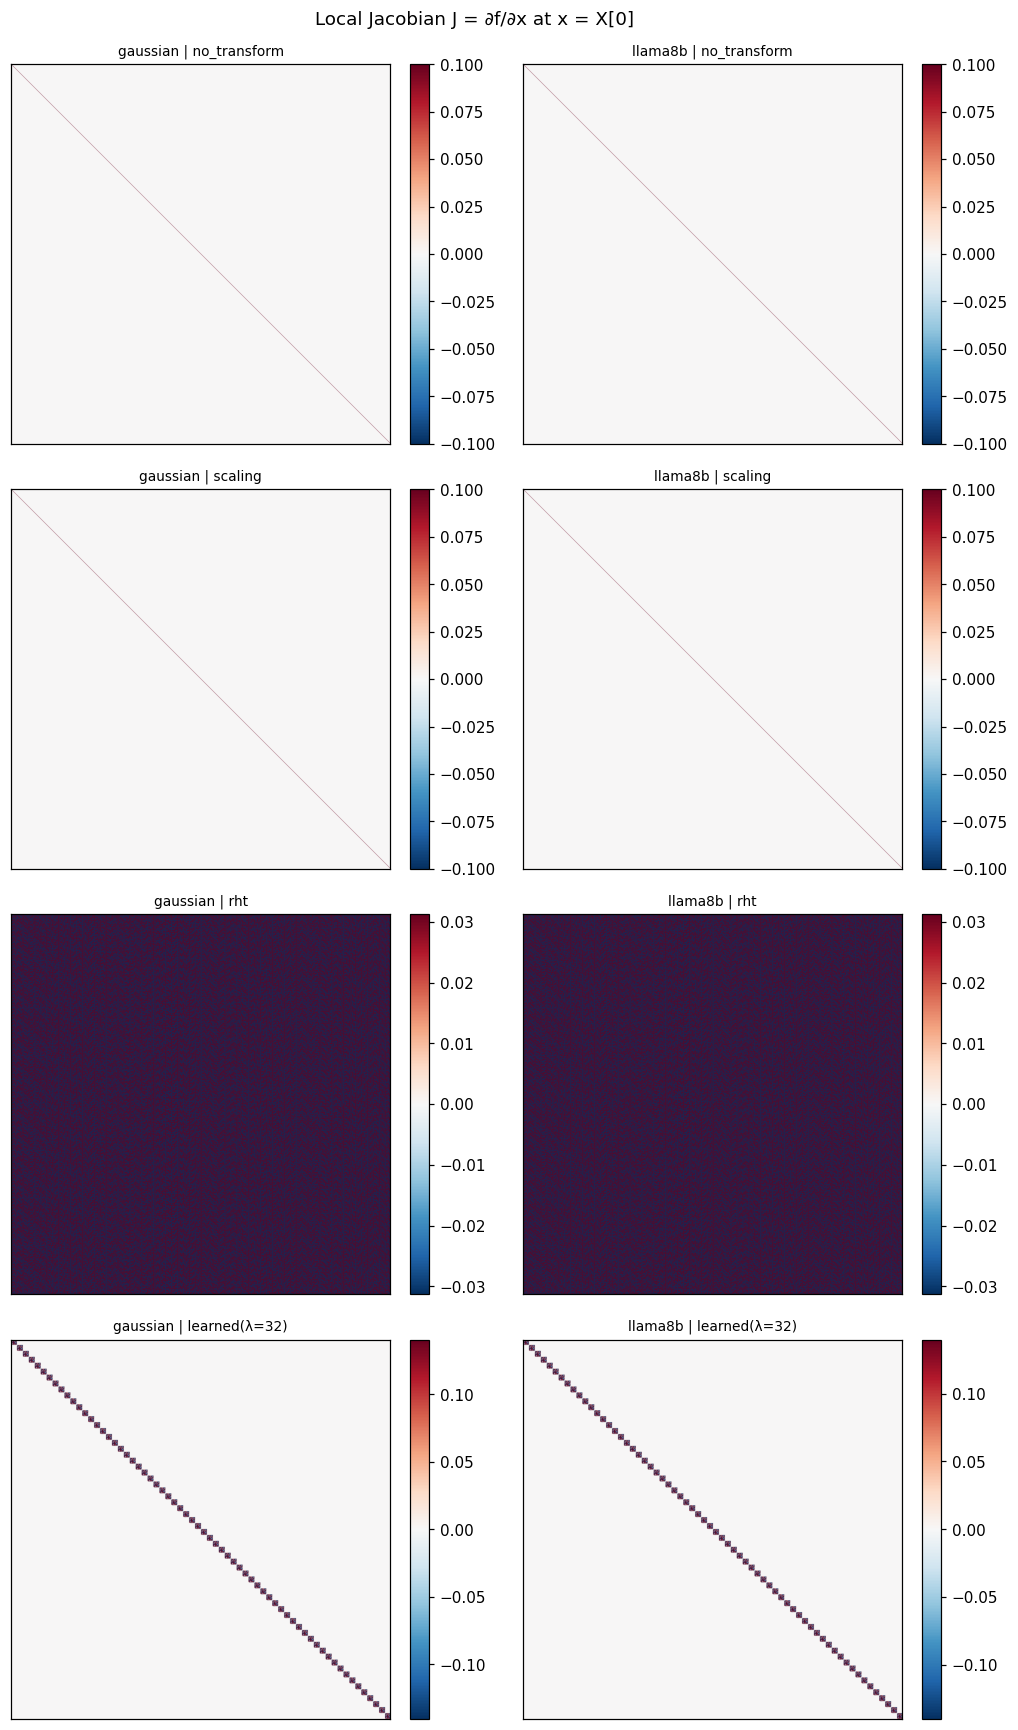

In [28]:
names_order = list(TRANSFORMS['gaussian'].keys())
datasets    = ['gaussian', 'llama8b']
n_rows      = len(names_order); n_cols = len(datasets)

# 5a. J heatmap
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), dpi=110)
if n_rows == 1: axes = axes[None, :]
for r, tname in enumerate(names_order):
    for c, ds in enumerate(datasets):
        if (ds, tname) not in JACOBIANS: continue
        J = JACOBIANS[(ds, tname)]
        ax = axes[r, c]
        vmax = float(J.abs().quantile(0.99))
        im = ax.imshow(J.numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(f'{ds} | {tname}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Local Jacobian J = ∂f/∂x at x = X[0]', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(FIG_DIR / 'jacobian_heatmaps.png')
plt.show()

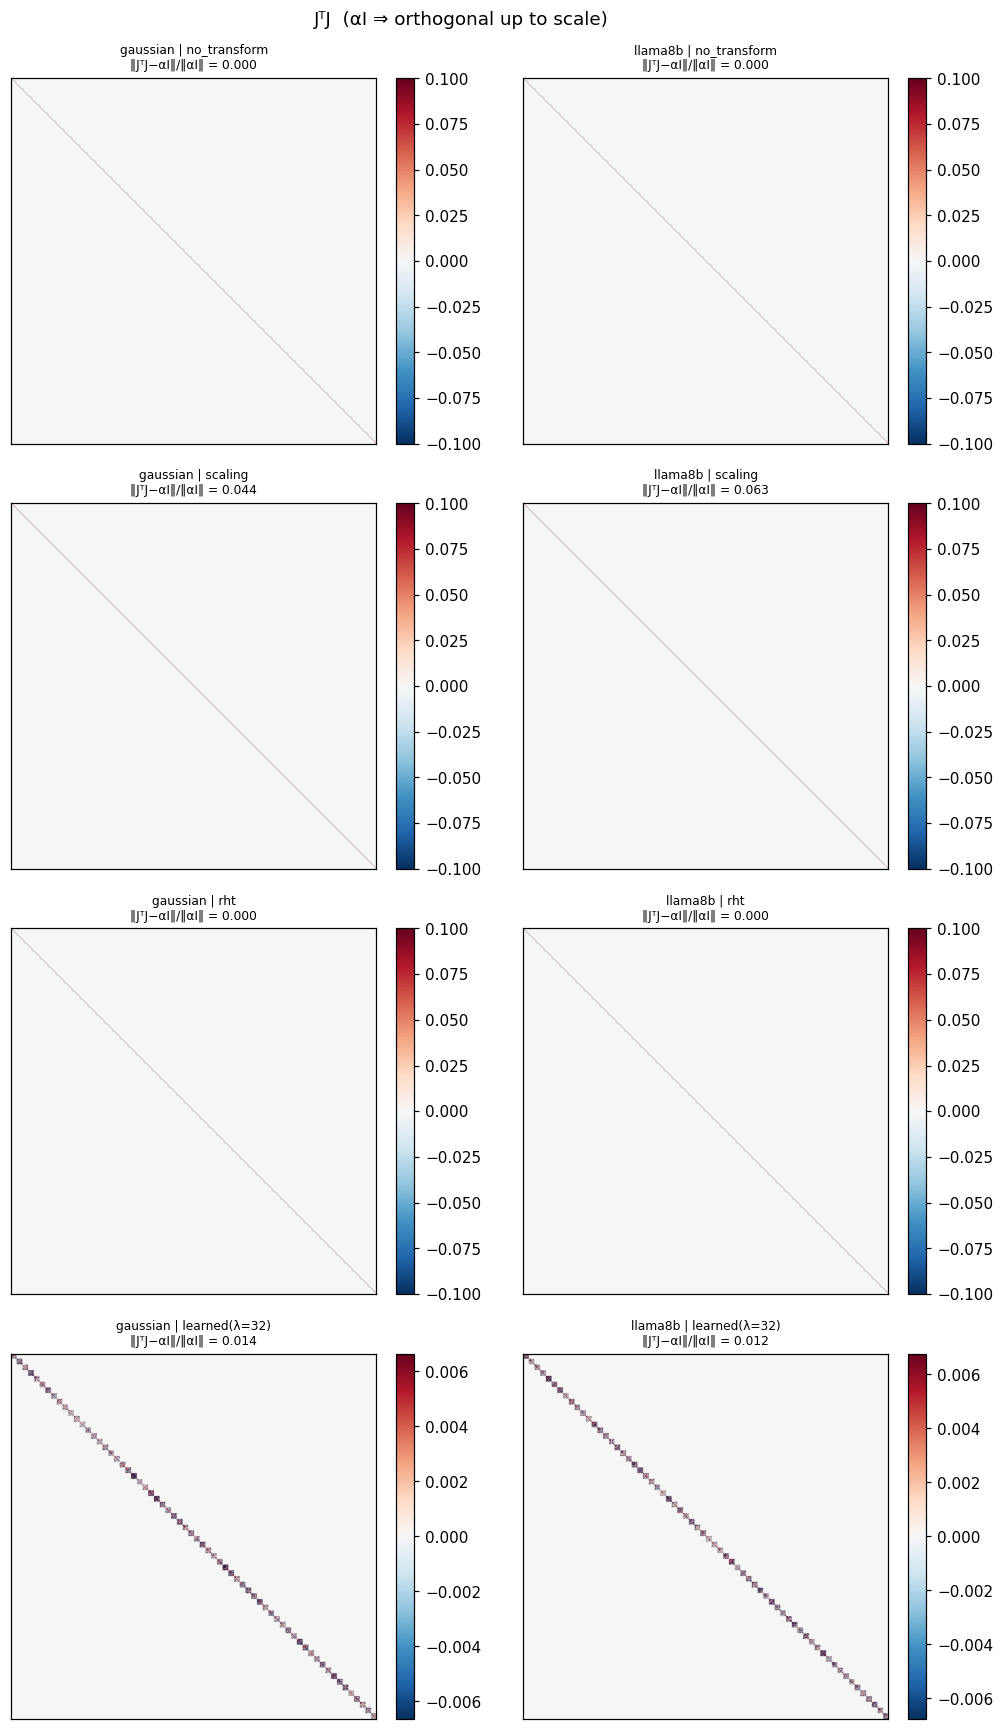

In [29]:
# 5b. JᵀJ — orthogonality
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), dpi=110)
if n_rows == 1: axes = axes[None, :]
for r, tname in enumerate(names_order):
    for c, ds in enumerate(datasets):
        if (ds, tname) not in JACOBIANS: continue
        J = JACOBIANS[(ds, tname)]
        G = J.T @ J
        ax = axes[r, c]
        vmax = float(G.abs().quantile(0.995))
        im = ax.imshow(G.numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        rel = RESULTS[(ds, tname)]['orthogonality']['frob_diff_rel']
        ax.set_title(f'{ds} | {tname}\n‖JᵀJ−αI‖/‖αI‖ = {rel:.3f}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('JᵀJ  (αI ⇒ orthogonal up to scale)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(FIG_DIR / 'JtJ_heatmaps.png')
plt.show()

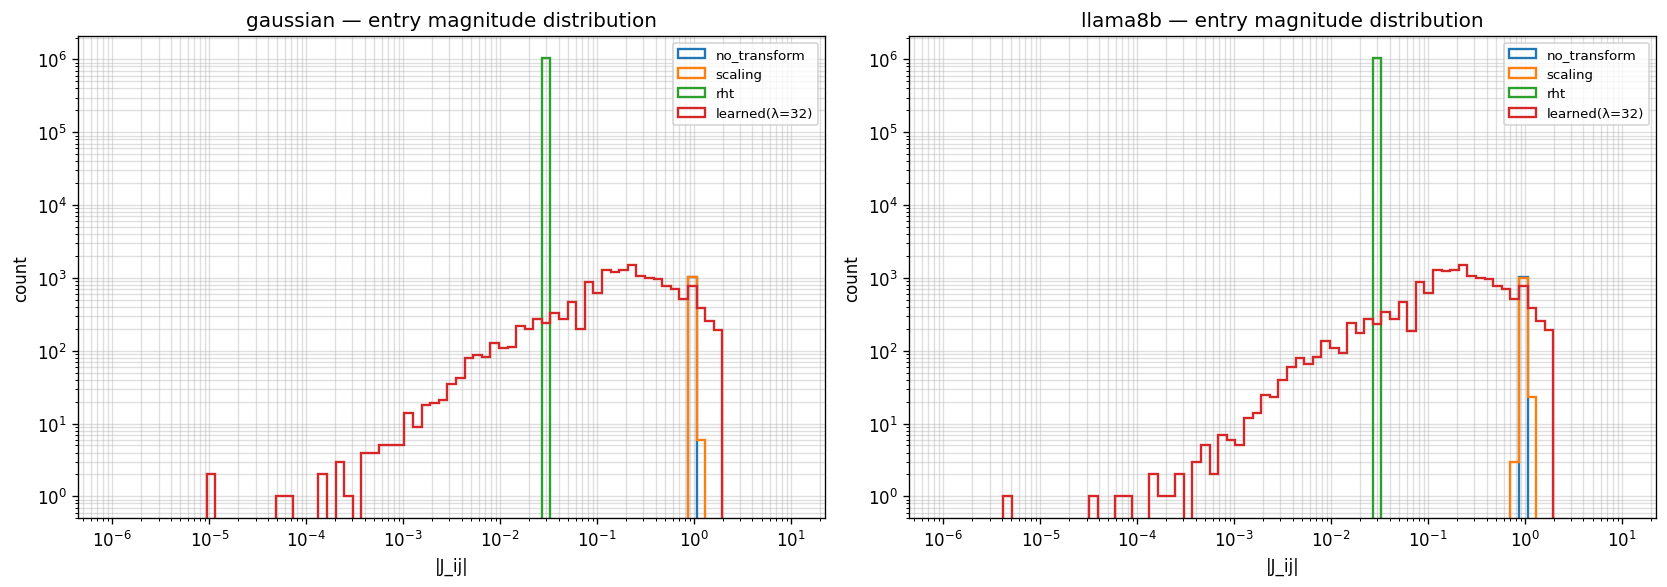

In [30]:
# 5c. Entry magnitude distribution (log-log)
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
bins = np.logspace(-6, 1, 80)
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        if (ds, tname) not in RESULTS: continue
        A = RESULTS[(ds, tname)]['entries']['A_flat']
        Ap = A[A > 1e-12]
        ax.hist(Ap, bins=bins, histtype='step', linewidth=1.4, label=tname)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('|J_ij|'); ax.set_ylabel('count')
    ax.set_title(f'{ds} — entry magnitude distribution')
    ax.grid(True, which='both', alpha=0.4); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'entry_distribution.png'); plt.show()

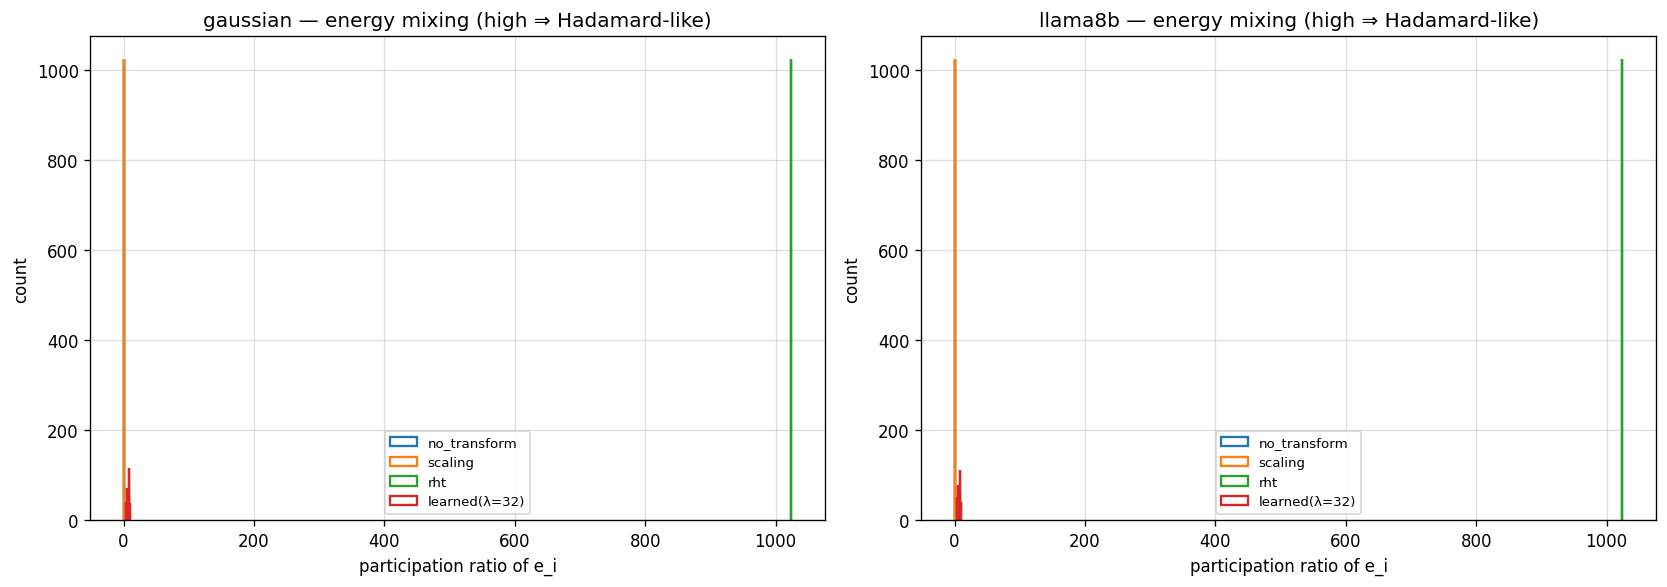

In [31]:
# 5d. Energy mixing — participation ratio per input basis
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        if (ds, tname) not in RESULTS: continue
        pr = RESULTS[(ds, tname)]['energy']['pr_per_col']
        ax.hist(pr, bins=80, histtype='step', linewidth=1.4, label=tname)
    ax.set_xlabel('participation ratio of e_i'); ax.set_ylabel('count')
    ax.set_title(f'{ds} — energy mixing (high ⇒ Hadamard-like)')
    ax.grid(True, alpha=0.4); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'energy_mixing.png'); plt.show()

In [32]:
# 5e. Summary table — covariance pre/post + key metrics
import pandas as pd
rows = []
for (ds, tname), m in RESULTS.items():
    rows.append({
        'dataset': ds, 'transform': tname,
        'ortho_rel': m['orthogonality']['frob_diff_rel'],
        'm2m_median': m['entries']['max_to_mean_median'],
        'participation_median': m['energy']['participation_median'],
        'cond_pre':  m['covariance']['pre']['cond'],
        'cond_post': m['covariance']['post']['cond'],
        'diag_dom_post': m['covariance']['post']['diag_dom'],
    })
df = pd.DataFrame(rows).sort_values(['dataset', 'transform']).reset_index(drop=True)
df.to_csv(FIG_DIR / 'summary_metrics.csv', index=False)
df

,dataset,transform,ortho_rel,m2m_median,participation_median,cond_pre,cond_post,diag_dom_post
0,gaussian,learned(λ=32),0.013579,227.260468,8.043521,13520513.0,5.297682e+06,25.523413
1,gaussian,no_transform,0.000000,1024.000000,1.000000,13520513.0,1.352051e+07,25.549137
2,gaussian,rht,0.000000,1.000000,1024.000000,13520513.0,3.057392e+06,25.523970
3,gaussian,scaling,0.044364,1024.000000,1.000000,13520513.0,7.230226e+06,25.562099
4,llama8b,learned(λ=32),0.011745,227.352737,8.026950,4543030.5,2.865573e+13,26.686663
5,llama8b,no_transform,0.000000,1024.000000,1.000000,4543030.5,4.543030e+06,26.570358
6,llama8b,rht,0.000000,1.000000,1024.000000,4543030.5,1.251612e+07,26.778385
7,llama8b,scaling,0.063255,1024.000000,1.000000,4543030.5,3.285039e+06,26.574642


## 6. Direct latent comparison
Beyond the local Jacobian (§3–5), look at what the transforms *actually do* to the data
distribution. We collect z = f(X) for every (dataset, transform) and use those latents
for distribution shaping (§7), information reallocation (§8), and quantization-error
robustness (§9). A 2-D toy (§10) provides geometric intuition.


In [33]:
# Cache z = f(X) for every (dataset, transform).
LATENTS = {}
for ds_name, X in [('gaussian', X_GAUSS), ('llama8b', X_LLAMA)]:
    for tname, tf in TRANSFORMS[ds_name].items():
        with torch.no_grad():
            z = tf(X).detach().cpu()
        LATENTS[(ds_name, tname)] = z
        print(f'{ds_name:8s} | {tname:18s}  z.shape={tuple(z.shape)}  '
              f'mean={float(z.mean()):+.3f}  std={float(z.std()):.3f}')


gaussian | no_transform        z.shape=(1024, 1024)  mean=-0.001  std=1.000
gaussian | scaling             z.shape=(1024, 1024)  mean=-0.001  std=1.000
gaussian | rht                 z.shape=(1024, 1024)  mean=-0.001  std=1.000
gaussian | learned(λ=32)       z.shape=(1024, 1024)  mean=+0.274  std=2.350
llama8b  | no_transform        z.shape=(1024, 1024)  mean=+0.000  std=0.999
llama8b  | scaling             z.shape=(1024, 1024)  mean=+0.000  std=1.000
llama8b  | rht                 z.shape=(1024, 1024)  mean=+0.000  std=0.999
llama8b  | learned(λ=32)       z.shape=(1024, 1024)  mean=+0.276  std=2.348


## 7. Distribution shaping (Figure 1)
Does the transform make the distribution easier to quantize?
- **7a. Latent value histogram** — heavy tails / outliers / compactness
- **7b. Sorted per-channel std** — channel scale imbalance
- **7c. |Correlation| heatmap** — decorrelation


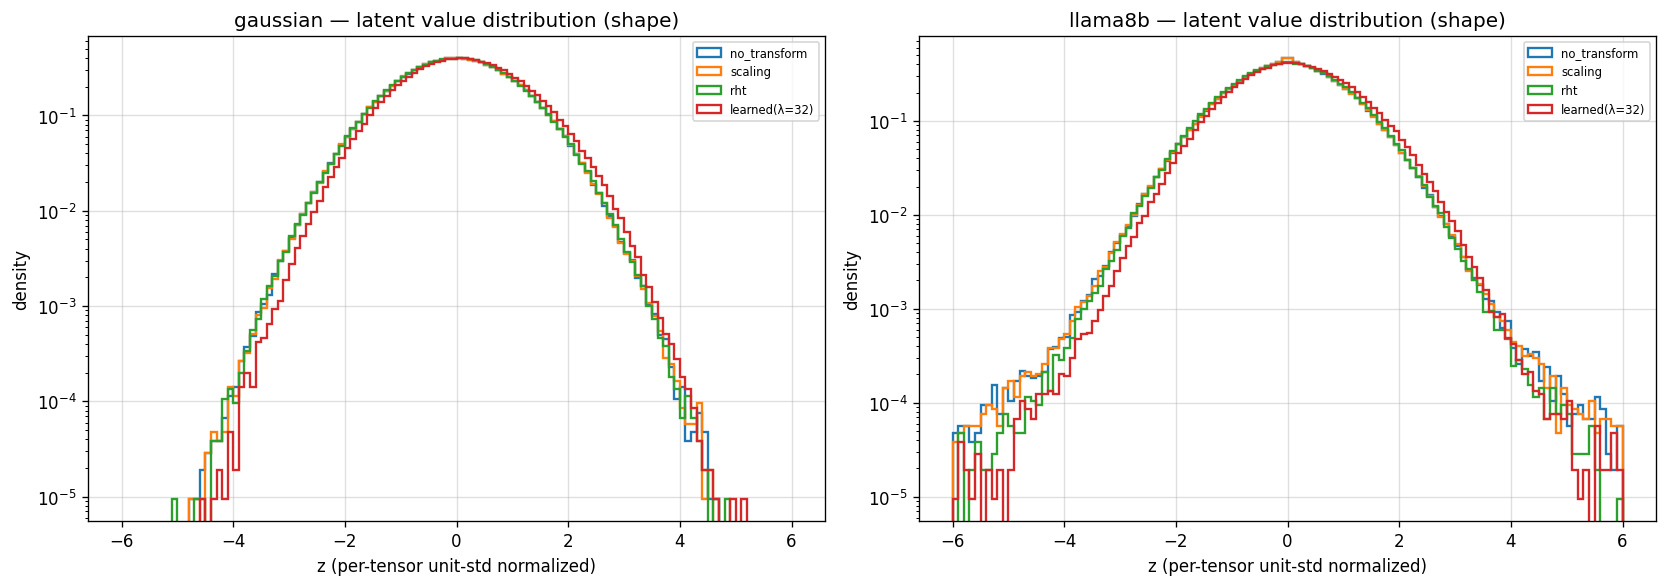

In [34]:
# 7a. Latent value distribution (per-tensor std-normalized for fair shape comparison)
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
bins = np.linspace(-6, 6, 121)
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        z = LATENTS[(ds, tname)].flatten().numpy()
        z = z / (z.std() + 1e-12)        # unit std → compare *shape*
        ax.hist(z, bins=bins, histtype='step', density=True, linewidth=1.4, label=tname)
    ax.set_yscale('log')
    ax.set_xlabel('z (per-tensor unit-std normalized)')
    ax.set_ylabel('density')
    ax.set_title(f'{ds} — latent value distribution (shape)')
    ax.grid(True, alpha=0.4); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig1a_value_hist.png'); plt.show()


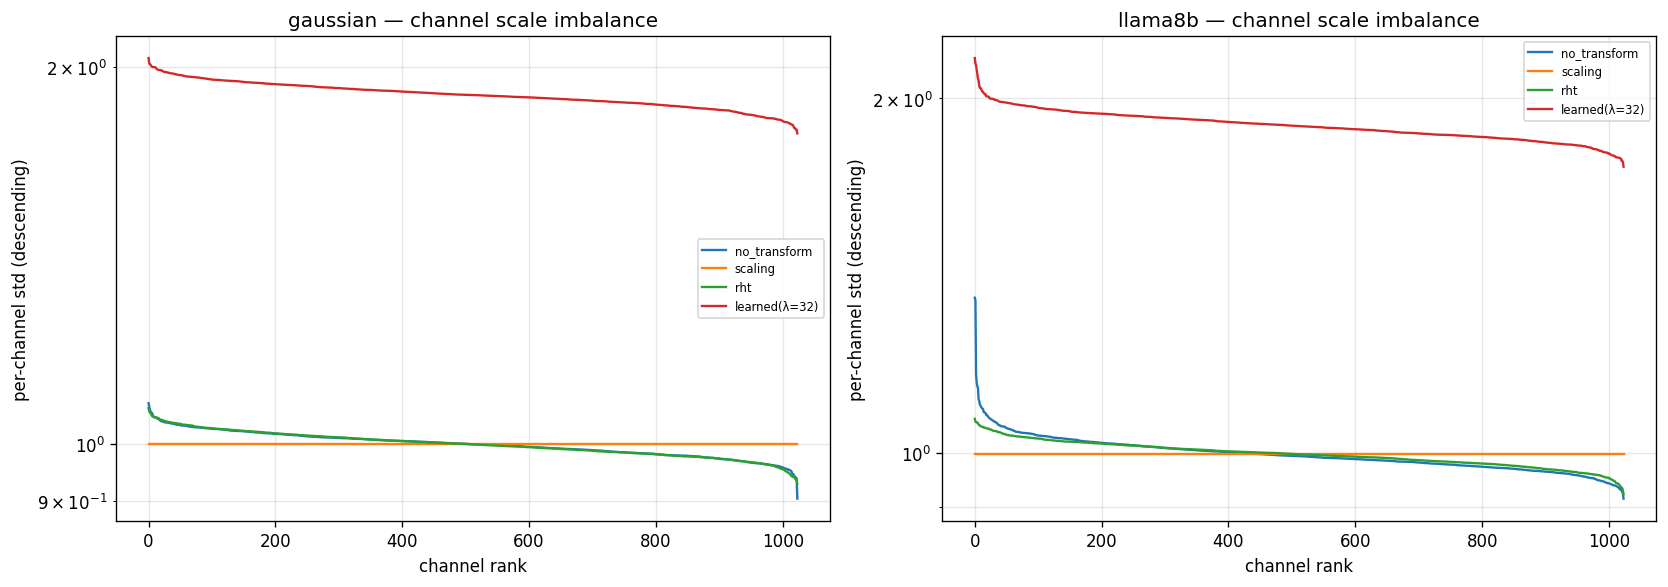

In [35]:
# 7b. Sorted per-channel std — shows scale imbalance across the 1024 dims
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        z = LATENTS[(ds, tname)].numpy()
        sigma = z.std(axis=0)
        sigma_sorted = np.sort(sigma)[::-1]
        ax.plot(sigma_sorted, label=tname, linewidth=1.4)
    ax.set_yscale('log')
    ax.set_xlabel('channel rank')
    ax.set_ylabel('per-channel std (descending)')
    ax.set_title(f'{ds} — channel scale imbalance')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig1b_sorted_std.png'); plt.show()


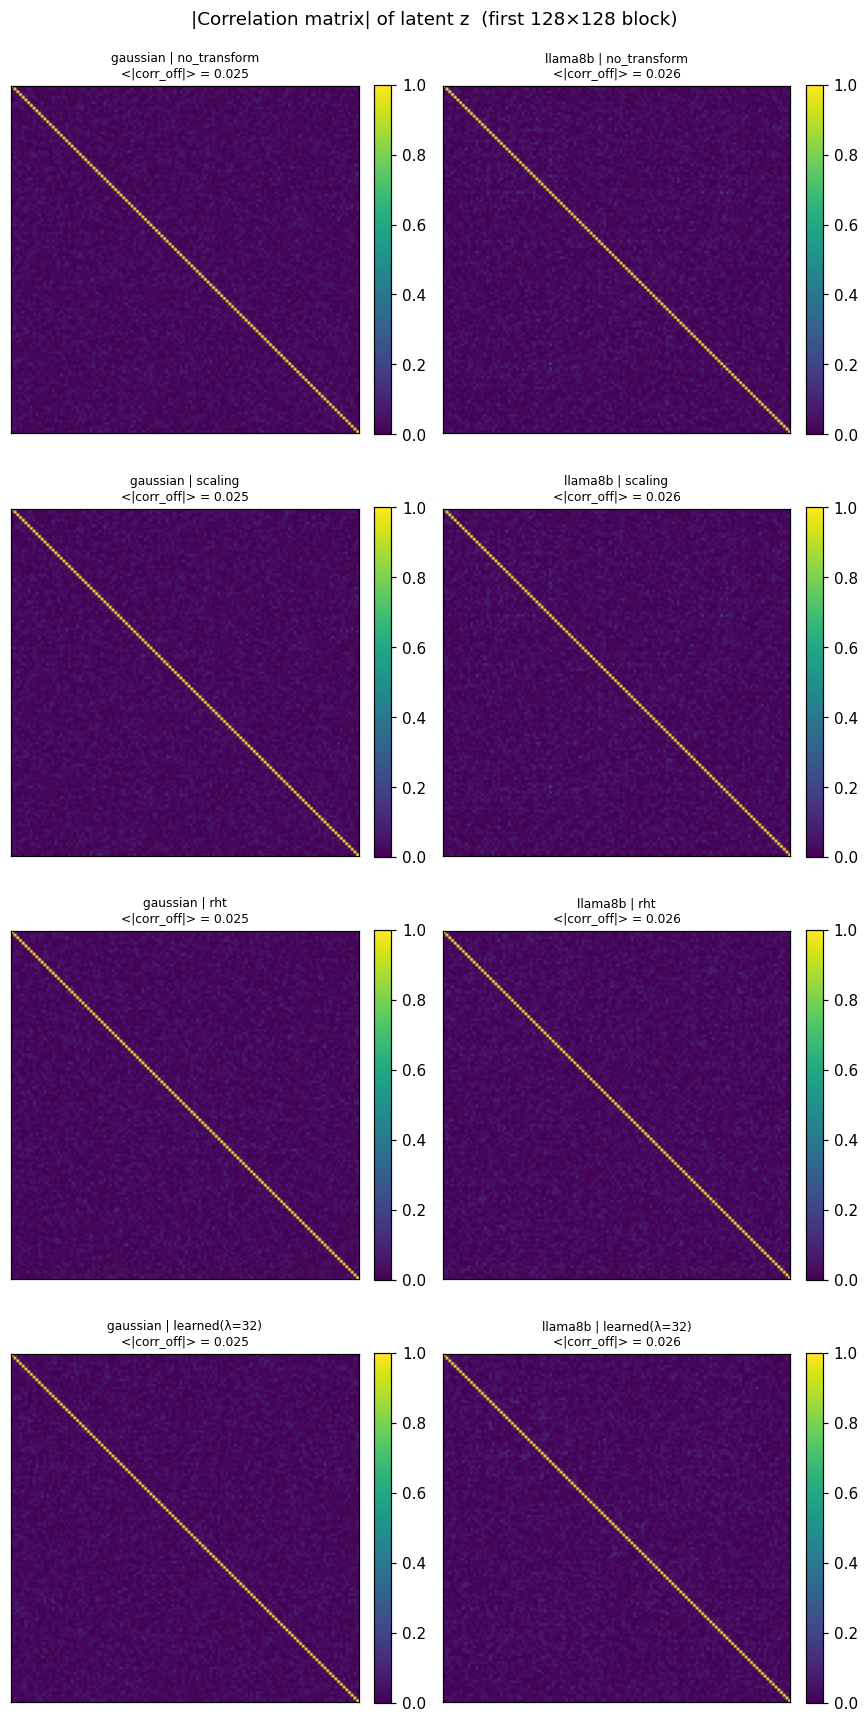

In [36]:
# 7c. |Correlation| heatmap  (full DxD computed; first 128 dims shown for legibility)
SHOW = 128
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), dpi=110)
if n_rows == 1: axes = axes[None, :]
for r, tname in enumerate(names_order):
    for c, ds in enumerate(datasets):
        z = LATENTS[(ds, tname)].numpy()
        zc = z - z.mean(axis=0, keepdims=True)
        zn = zc / (zc.std(axis=0, keepdims=True) + 1e-12)
        D = zn.shape[1]
        corr = (zn.T @ zn) / zn.shape[0]
        off = corr - np.diag(np.diag(corr))
        off_mean = float(np.abs(off).sum() / (D*D - D))
        ax = axes[r, c]
        im = ax.imshow(np.abs(corr[:SHOW, :SHOW]), cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'{ds} | {tname}\n<|corr_off|> = {off_mean:.3f}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f'|Correlation matrix| of latent z  (first {SHOW}×{SHOW} block)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(FIG_DIR / 'fig1c_corr_heatmap.png'); plt.show()


## 8. Information reallocation (Figure 2)
Sorted variance spectrum and cumulative energy curve.
- *Energy compaction* (variance concentrated in few dims) ⇒ classic transform-coding gain.
- *Energy equalization* (flat curve) ⇒ Hadamard-like spreading; uniform per-dim quantization budget is then optimal.
The "good" answer depends on the downstream entropy model — this plot reveals which strategy each transform learned.


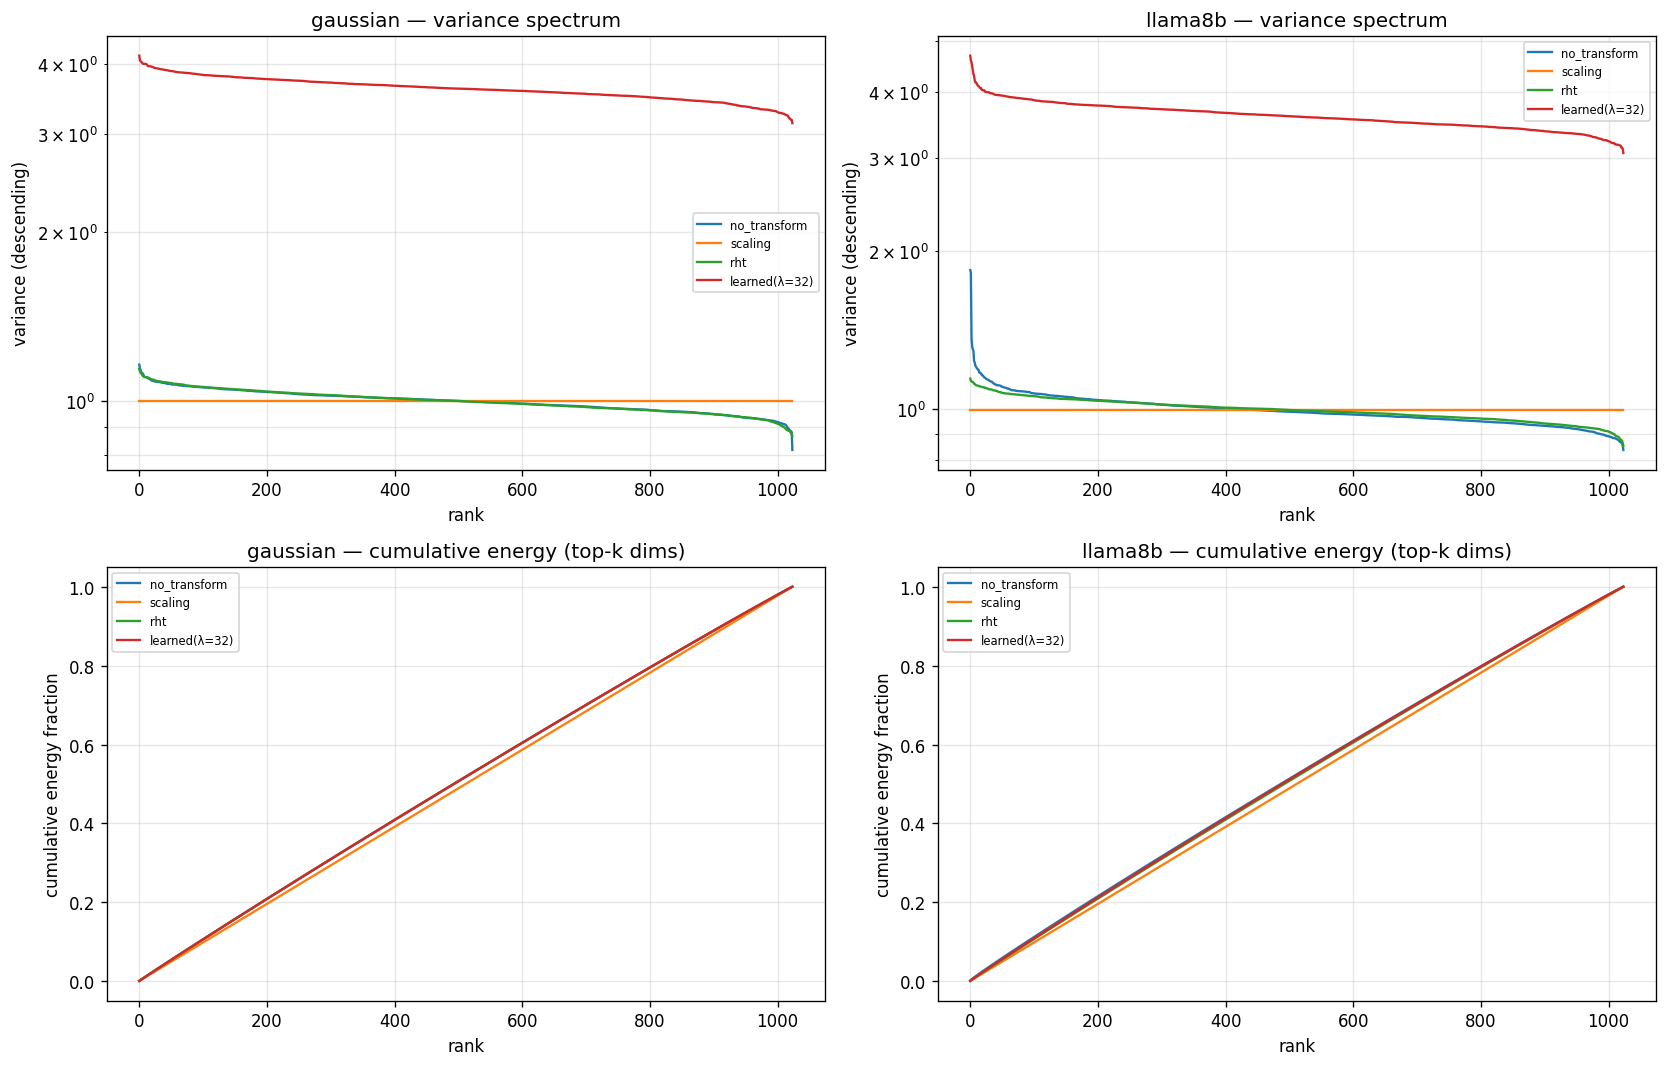

In [37]:
# 8a/8b. Variance spectrum + cumulative energy
fig, axes = plt.subplots(2, n_cols, figsize=(7*n_cols, 9), dpi=120)
if n_cols == 1: axes = axes[:, None]
for c, ds in enumerate(datasets):
    ax_v = axes[0, c]; ax_c = axes[1, c]
    for tname in names_order:
        z = LATENTS[(ds, tname)].numpy()
        v = z.var(axis=0)
        v_sorted = np.sort(v)[::-1]
        cum = np.cumsum(v_sorted) / max(v_sorted.sum(), 1e-12)
        ax_v.plot(v_sorted, label=tname, linewidth=1.4)
        ax_c.plot(cum,      label=tname, linewidth=1.4)
    ax_v.set_yscale('log')
    ax_v.set_xlabel('rank'); ax_v.set_ylabel('variance (descending)')
    ax_v.set_title(f'{ds} — variance spectrum')
    ax_v.grid(True, which='both', alpha=0.3); ax_v.legend(fontsize=7)
    ax_c.set_xlabel('rank'); ax_c.set_ylabel('cumulative energy fraction')
    ax_c.set_title(f'{ds} — cumulative energy (top-k dims)')
    ax_c.grid(True, alpha=0.3); ax_c.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig2_variance_spectrum.png'); plt.show()


## 9. Quantization noise effect (Figure 3)
Build inverse transforms, then sweep a per-channel uniform quantizer Δ_i = c·σ_i (matched
rate per dim) and measure the **reconstruction error in input space** ‖T⁻¹(Q(z)) − T⁻¹(z)‖².

This is the central question: does the transform put quantization noise in
*directions the inverse handles gracefully*?  We compare the extra distortion induced by
quantization (not the autoencoder reconstruction loss itself), so the learned transform's
imperfect identity does not unfairly penalize it.


In [38]:
# 9a. Build inverse transforms (mirror of TRANSFORMS).
def make_identity_inverse():
    return (lambda z: z.clone())

def make_scaling_inverse(X_ref):
    std = X_ref.float().std(dim=0).clamp_min(1e-9).to(DEVICE)
    def f(z): return z * std.unsqueeze(0)
    return f

def make_rht_inverse(dim=INPUT_DIM, seed=0):
    g = torch.Generator().manual_seed(seed)
    diag = (torch.randint(0, 2, (dim,), generator=g).mul(2).sub(1)).float().to(DEVICE)
    H = hadamard_matrix(dim).to(DEVICE)        # symmetric, orthogonal
    def f(z): return (z @ H) * diag.unsqueeze(0)
    return f

def make_learned_inverse(ckpt_path: str):
    model, args = load_learned_encoder(ckpt_path)
    decoder = model.g_s
    block = int(args.input_size)
    def f(z):
        B, D = z.shape
        nb = D // block
        x = decoder(z.reshape(B, nb, block).contiguous())
        return x.reshape(B, D)
    return f

INVERSES = {}
for ds_name, X_ref in [('gaussian', X_GAUSS), ('llama8b', X_LLAMA)]:
    Idict = OrderedDict()
    Idict['no_transform'] = make_identity_inverse()
    Idict['scaling']      = make_scaling_inverse(X_ref)
    Idict['rht']          = make_rht_inverse(dim=INPUT_DIM, seed=0)
    for L in LAMBDAS:
        ckpt = CKPT_GLOB.format(l=L)
        if not os.path.exists(ckpt): continue
        Idict[f'learned(λ={L})'] = make_learned_inverse(ckpt)
    INVERSES[ds_name] = Idict
    print(f'{ds_name}: inverses built for {list(Idict.keys())}')


gaussian: inverses built for ['no_transform', 'scaling', 'rht', 'learned(λ=32)']
llama8b: inverses built for ['no_transform', 'scaling', 'rht', 'learned(λ=32)']


gaussian | no_transform        NMSE@c=1.0 = 8.330e-02, NMSE@c=0.1 = 3.589e-04
gaussian | scaling             NMSE@c=1.0 = 8.330e-02, NMSE@c=0.1 = 3.589e-04
gaussian | rht                 NMSE@c=1.0 = 8.337e-02, NMSE@c=0.1 = 3.596e-04
gaussian | learned(λ=32)       NMSE@c=1.0 = 8.328e-02, NMSE@c=0.1 = 3.595e-04
llama8b  | no_transform        NMSE@c=1.0 = 8.229e-02, NMSE@c=0.1 = 3.585e-04
llama8b  | scaling             NMSE@c=1.0 = 8.229e-02, NMSE@c=0.1 = 3.585e-04
llama8b  | rht                 NMSE@c=1.0 = 8.297e-02, NMSE@c=0.1 = 3.592e-04
llama8b  | learned(λ=32)       NMSE@c=1.0 = 8.323e-02, NMSE@c=0.1 = 3.588e-04


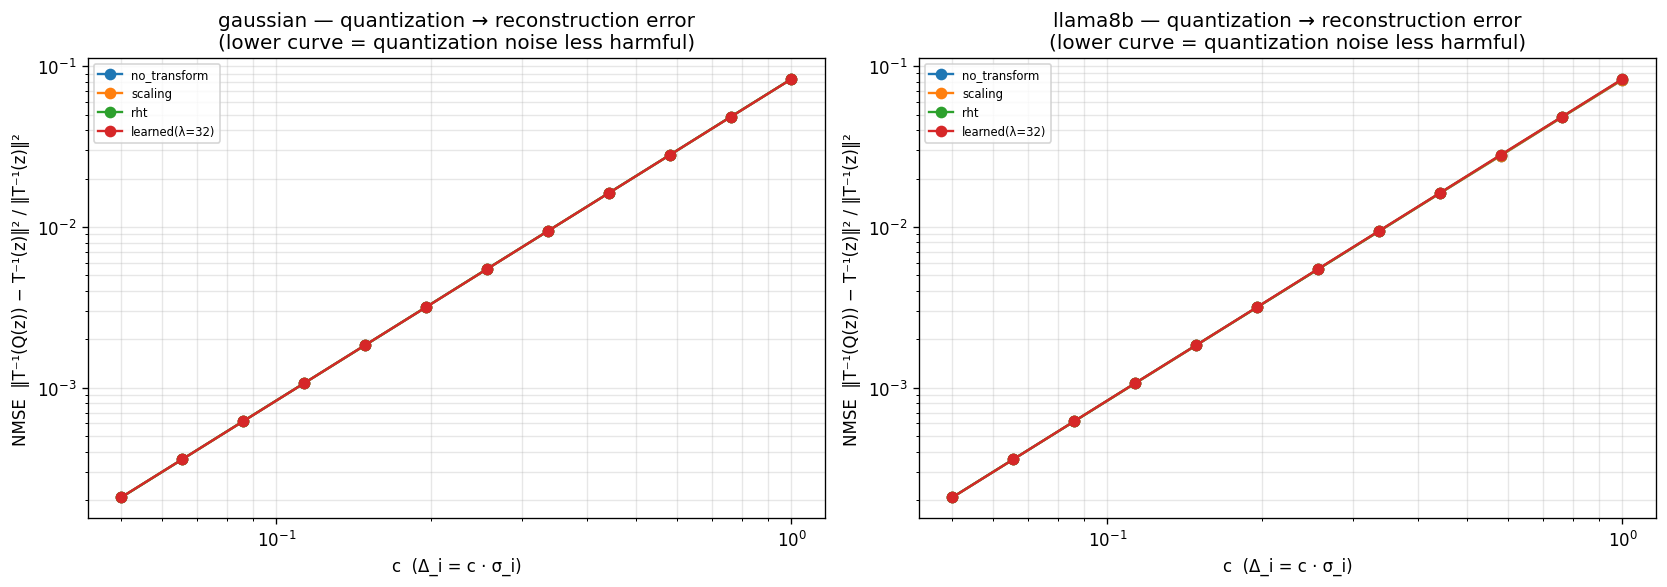

In [39]:
# 9b. RD sweep — Δ_i = c·σ_i quantizer; report NMSE in input space relative to T^-1(z)
@torch.no_grad()
def rd_sweep(z, inv, cs):
    sigma = z.std(dim=0, keepdim=True).clamp_min(1e-9)
    x_ref = inv(z)
    denom = (x_ref ** 2).mean().clamp_min(1e-12)
    out = []
    for c in cs:
        Delta = c * sigma
        zq = torch.round(z / Delta) * Delta
        x_rec = inv(zq)
        nmse = ((x_rec - x_ref) ** 2).mean() / denom
        out.append(float(nmse.item()))
    return np.array(out)

CS = np.geomspace(0.05, 1.0, 12)
RD = {}
for ds_name, X in [('gaussian', X_GAUSS), ('llama8b', X_LLAMA)]:
    for tname, tf in TRANSFORMS[ds_name].items():
        with torch.no_grad():
            z = tf(X)
        nmse = rd_sweep(z, INVERSES[ds_name][tname], CS)
        RD[(ds_name, tname)] = nmse
        print(f'{ds_name:8s} | {tname:18s}  NMSE@c=1.0 = {nmse[-1]:.3e}, '
              f'NMSE@c=0.1 = {nmse[1]:.3e}')

# Plot
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c_, ds in enumerate(datasets):
    ax = axes[c_]
    for tname in names_order:
        ax.plot(CS, RD[(ds, tname)], label=tname, marker='o', linewidth=1.4)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('c  (Δ_i = c · σ_i)')
    ax.set_ylabel('NMSE  ‖T⁻¹(Q(z)) − T⁻¹(z)‖² / ‖T⁻¹(z)‖²')
    ax.set_title(f'{ds} — quantization → reconstruction error\n(lower curve = quantization noise less harmful)')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig3_quant_recon_error.png'); plt.show()


## 10. 2-D toy (Figure 4)
Same comparison on 2-D correlated Gaussian for geometric intuition.  Each panel shows
the post-transform point cloud with a uniform scalar quantization grid overlaid.
- **No transform**: tilted ellipse — long diagonal escapes through many cells.
- **Scaling (per-axis std)**: axis-aligned scale, but correlation remains; cells still cut the ellipse poorly.
- **RHT (2D Hadamard)**: rotated by 45°; isotropy unchanged (Hadamard ≡ rotation).
- **Whitening** (PCA whitening, used as the *learned-ideal* stand-in since the trained encoder is 16-dim): aligned to a round cloud — quantization cells well-matched.

Caveat: the actual learned encoder is block-wise 16-dim and cannot be re-used in 2-D.
The "whitening" panel shows what an *ideal* learned 2-D transform would look like.


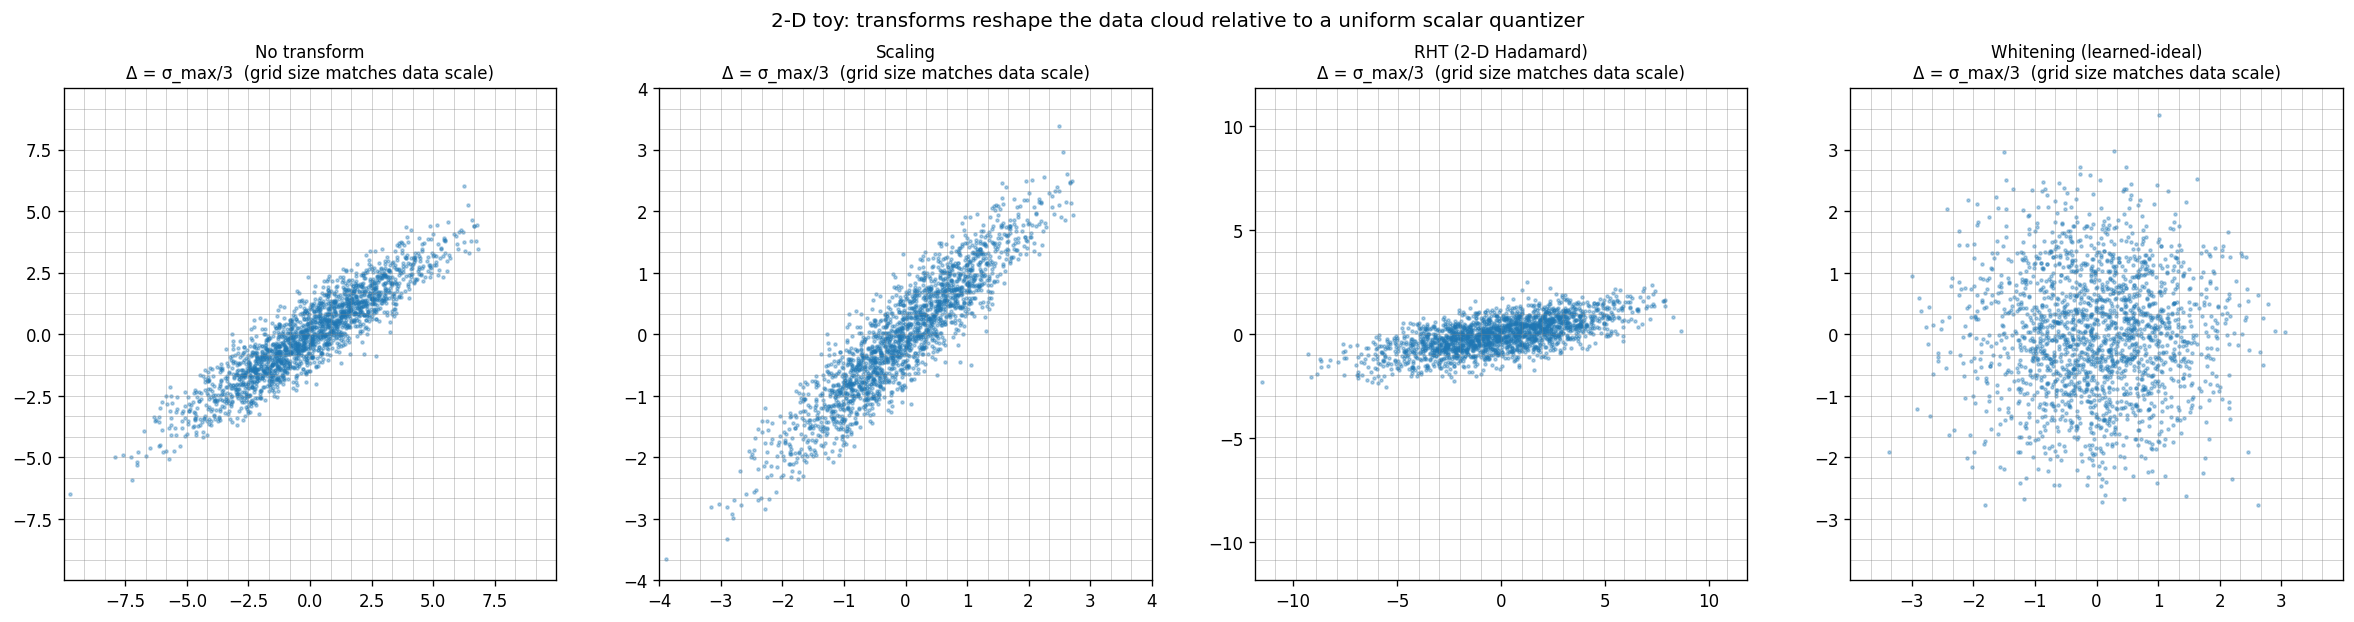

: 

In [ ]:
# 10. 2-D toy: 4 transforms applied to a 2-D correlated Gaussian, with quantization grid

def quantize_grid_lines(ax, x_min, x_max, y_min, y_max, delta, color='gray', alpha=0.35):
    xs = np.arange(np.floor(x_min/delta)*delta, x_max + delta, delta)
    ys = np.arange(np.floor(y_min/delta)*delta, y_max + delta, delta)
    for x in xs:
        ax.axvline(x, color=color, alpha=alpha, linewidth=0.6)
    for y in ys:
        ax.axhline(y, color=color, alpha=alpha, linewidth=0.6)

# 2D correlated Gaussian (anisotropic, tilted)
N2D = 2000
rng = np.random.default_rng(0)
theta = np.deg2rad(35.0)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
S = np.diag([3.0, 0.6])                 # large/small axes
X2 = rng.standard_normal((N2D, 2)) @ (R @ S).T

# Transforms
def t_identity(X): return X.copy()

def t_scaling(X):
    return X / X.std(axis=0, keepdims=True)

def t_rht(X):
    H = np.array([[1.0, 1.0], [1.0, -1.0]]) / np.sqrt(2.0)
    g = np.random.default_rng(0)
    diag = g.choice([-1.0, 1.0], size=2)
    return (X * diag) @ H.T

def t_whitening(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    cov = (Xc.T @ Xc) / (Xc.shape[0] - 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    W = eigvecs @ np.diag(1.0 / np.sqrt(np.clip(eigvals, 1e-12, None))) @ eigvecs.T
    return Xc @ W

panels = [('No transform',            t_identity),
          ('Scaling',                 t_scaling),
          ('RHT (2-D Hadamard)',      t_rht),
          ('Whitening (learned-ideal)', t_whitening)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=120)
for ax, (name, fn) in zip(axes, panels):
    Y = fn(X2)
    # Choose Δ so the cloud spans ~10 cells along its larger axis
    span = float(Y.std(axis=0).max())
    delta = span / 3.0
    lim = 4.0 * span
    quantize_grid_lines(ax, -lim, lim, -lim, lim, delta)
    ax.scatter(Y[:, 0], Y[:, 1], s=3, alpha=0.35, color='C0')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_title(f'{name}\nΔ = σ_max/3  (grid size matches data scale)', fontsize=10)
    ax.grid(False)
fig.suptitle('2-D toy: transforms reshape the data cloud relative to a uniform scalar quantizer', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIG_DIR / 'fig4_2d_toy.png'); plt.show()


## 11. Interpretation guide (Jacobian-based, §3–5)
Reference values (analytical):

| Transform        | ortho_rel | max_to_mean (per row) | participation per col | diag_dom_post |
|------------------|-----------|------------------------|------------------------|---------------|
| **No transform** | 0.0       | ∞ (single nonzero/row) | 1                      | unchanged     |
| **Scaling**      | small (still diagonal but per-channel scale ≠ I) | ∞ | 1 | unchanged structure |
| **RHR**          | 0.0       | 1.0 (uniform)          | D=1024                 | low (decorrelated) |
| **Learned**      | between scaling and RHR | depends | depends | depends |

If the learned encoder's metrics line up close to RHR's row, then it has effectively learned a Hadamard-like rotation. If they look more like scaling/identity, then it preserves coordinate axes.